In [2]:
from pathlib import Path
import pandas as pd
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Your project imports
import util.read_price as read_price
from src.analysis.forecast_accuracy_IP import (
    evaluate_ip_deterministic,
    evaluate_ip_probabilistic,
    plot_det_horizon_metrics,
    plot_prob_coverage,
    plot_calibration_curve,
    plot_prob_crps,
    plot_prob_sharpness
)


PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "Data"


In [3]:
# Load real prices (15-min)
ip_real = read_price.read_ip_real_prices(
    data_dir=DATA_DIR,
    freq="15min",
    keep_extra_columns=False,
    verbose=True,
)["Price"]

ip_real.index.min(), ip_real.index.max()


(Timestamp('2021-01-01 00:00:00'), Timestamp('2023-12-31 23:45:00'))

In [4]:
# Deterministic forecast 
ip_det = read_price.read_ip_forecast(
    model="QR",
    kind="deterministic",
    data_dir=DATA_DIR,
    freq="15min",
    verbose=True,
)



In [5]:
det_metrics = evaluate_ip_deterministic(
    ip_det,
    ip_real,
    dt=pd.Timedelta("15min"),   # explicit, recommended
    base_offset_steps=0,        # qh1 matches y at same timestamp
)
det_metrics


,MAE,RMSE,N
horizon,,,
1,71.109629,110.191133,37913
2,83.898362,122.240422,37913
3,89.094789,128.155748,37913
4,91.251881,130.819851,37913
5,94.687956,134.150410,37913
6,96.311343,136.097883,37913
7,97.000918,136.988817,37913
8,97.556721,137.816997,37913


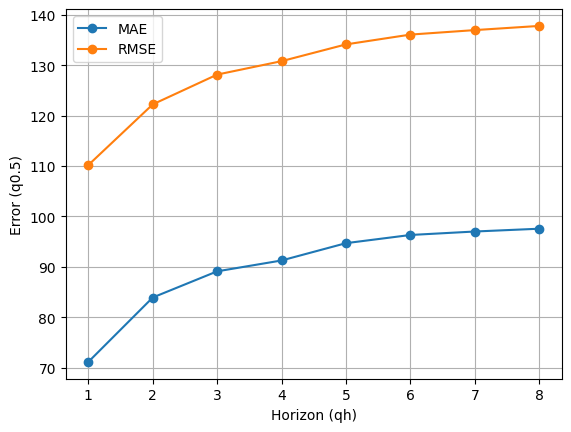

In [6]:
plot_det_horizon_metrics(det_metrics, title="")


In [7]:
# Probabilistic forecast (example: QR or LEAR depending on what you have)
ip_prob = read_price.read_ip_forecast(
    model="QR",
    kind="probabilistic",
    data_dir=DATA_DIR,
    freq="15min",
    verbose=True,
)



In [8]:
prob_out = evaluate_ip_probabilistic(
    ip_prob,
    ip_real,
    dt=pd.Timedelta("15min"),
    intervals=((0.01, 0.99), (0.05, 0.95),(0.1, 0.9), (0.2, 0.8), (0.3, 0.7), (0.4, 0.6)),
    base_offset_steps=0,
)

prob_out["coverage"]


,"[q0.01, q0.99]","[q0.05, q0.95]","[q0.1, q0.9]","[q0.2, q0.8]","[q0.3, q0.7]","[q0.4, q0.6]",N
horizon,,,,,,,
1,0.978714,0.919790,0.836019,0.644238,0.431356,0.219608,37913
2,0.980482,0.920080,0.840662,0.652177,0.448870,0.225068,37913
3,0.979400,0.918603,0.840767,0.654182,0.445916,0.222984,37913
4,0.979189,0.919052,0.839870,0.654208,0.444465,0.223063,37913
5,0.979005,0.919711,0.842587,0.659009,0.452826,0.233113,37913
6,0.978820,0.919922,0.843378,0.659220,0.456572,0.237254,37913
7,0.978081,0.920449,0.842903,0.659932,0.457759,0.238282,37913
8,0.978609,0.920608,0.842798,0.660328,0.458260,0.239443,37913


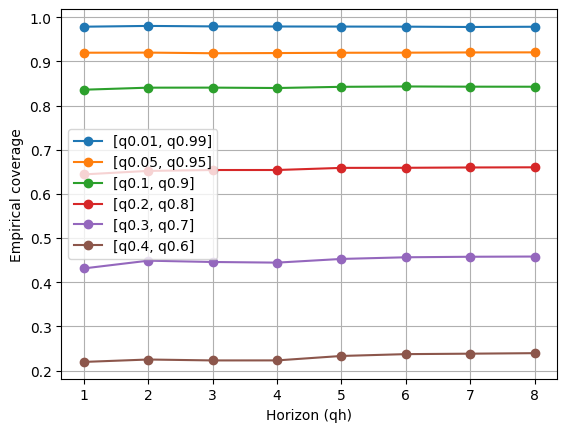

In [9]:
plot_prob_coverage(prob_out["coverage"], title="")


In [10]:
prob_out


{'coverage':          [q0.01, q0.99]  [q0.05, q0.95]  [q0.1, q0.9]  [q0.2, q0.8]  \
 horizon                                                               
 1              0.978714        0.919790      0.836019      0.644238   
 2              0.980482        0.920080      0.840662      0.652177   
 3              0.979400        0.918603      0.840767      0.654182   
 4              0.979189        0.919052      0.839870      0.654208   
 5              0.979005        0.919711      0.842587      0.659009   
 6              0.978820        0.919922      0.843378      0.659220   
 7              0.978081        0.920449      0.842903      0.659932   
 8              0.978609        0.920608      0.842798      0.660328   
 
          [q0.3, q0.7]  [q0.4, q0.6]      N  
 horizon                                     
 1            0.431356      0.219608  37913  
 2            0.448870      0.225068  37913  
 3            0.445916      0.222984  37913  
 4            0.444465      0.223063

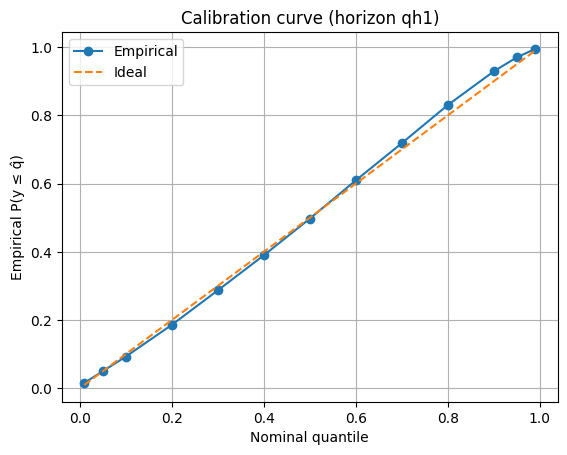

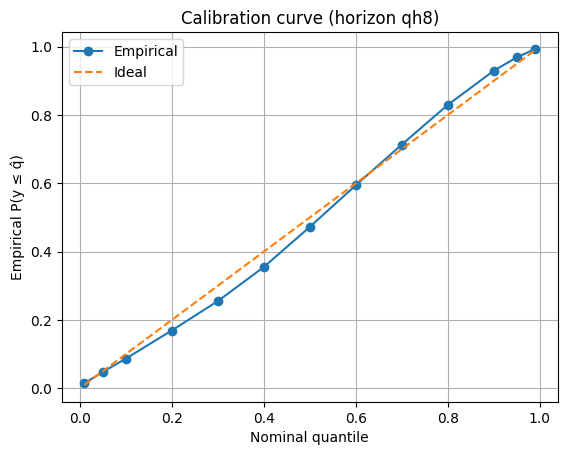

In [11]:
# Calibration curve for a chosen horizon
plot_calibration_curve(prob_out["calibration"], horizon=1)

plot_calibration_curve(prob_out["calibration"], horizon=8)

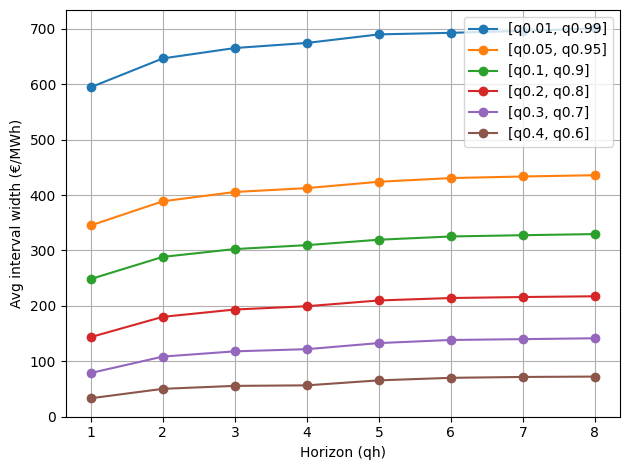

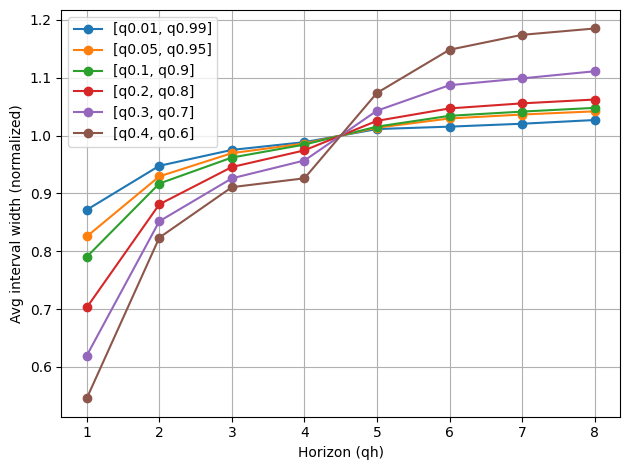

In [12]:
plot_prob_sharpness(prob_out["sharpness"], title="")
# or normalized
plot_prob_sharpness(prob_out["sharpness"], title="", normalize=True)

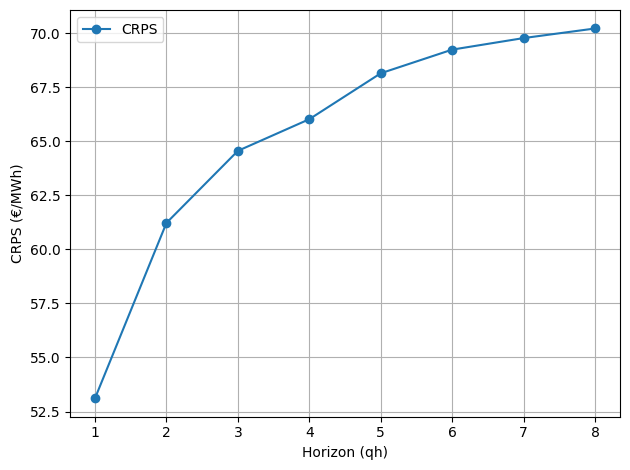

In [13]:
plot_prob_crps(prob_out["crps"], title="")


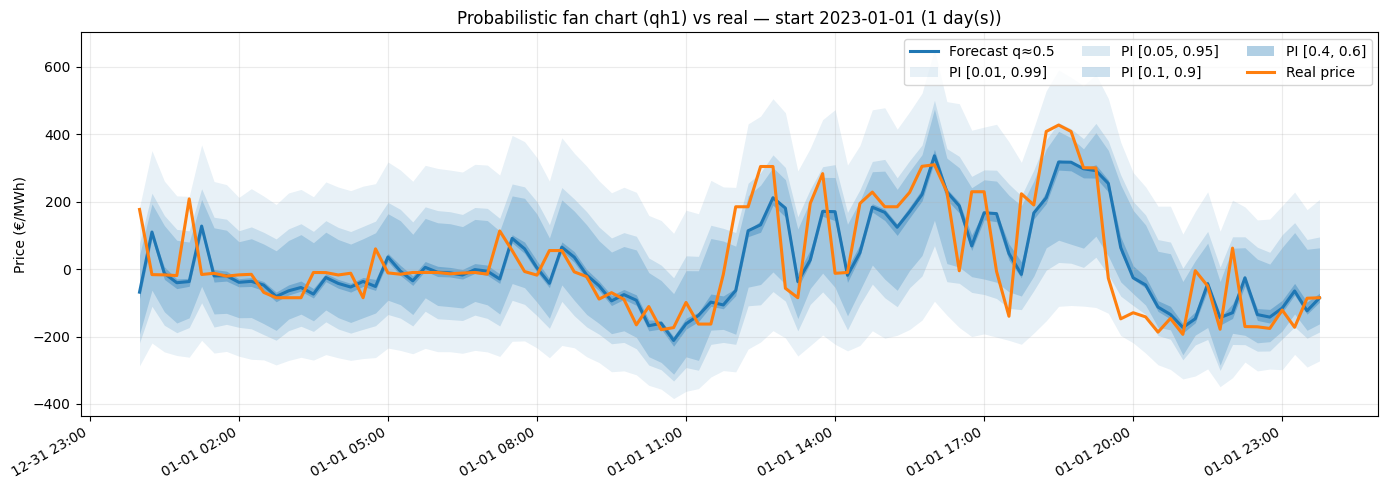

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
from typing import Optional, Union


_qh_q_re = re.compile(r"^qh(\d+)_q([01](?:\.\d+)?)$")


def _extract_qh_quantiles(prob: pd.DataFrame, h: int = 1):
    qs, cols = [], []
    for c in prob.columns:
        m = _qh_q_re.match(str(c))
        if not m:
            continue
        hh = int(m.group(1))
        if hh != h:
            continue
        q = float(m.group(2))
        qs.append(q)
        cols.append(c)

    if not qs:
        raise ValueError(f"No columns found for horizon qh{h} with pattern 'qh{h}_q{{q}}'.")

    order = np.argsort(qs)
    q_sorted = np.array([qs[i] for i in order], dtype=float)
    cols_sorted = [cols[i] for i in order]
    return q_sorted, cols_sorted


def pick_random_day_index(prob_index: pd.DatetimeIndex, real_index: pd.DatetimeIndex, *, min_points=80, seed=0):
    common = prob_index.intersection(real_index)
    if common.empty:
        raise ValueError("No overlapping timestamps between probabilistic forecast and real series.")
    day_counts = common.to_series().dt.normalize().value_counts().sort_index()
    eligible_days = day_counts[day_counts >= min_points].index.to_list()
    if not eligible_days:
        eligible_days = day_counts.index.to_list()
    rng = np.random.default_rng(seed)
    return pd.Timestamp(rng.choice(eligible_days))


def plot_prob_fan(
    ip_prob: pd.DataFrame,
    ip_real: pd.Series,
    *,
    start_day: Optional[Union[pd.Timestamp, str]] = None,
    days: int = 1,
    horizon: int = 1,
    intervals=((0.01, 0.99), (0.05, 0.95), (0.10, 0.90), (0.25, 0.75), (0.40, 0.60)),
    seed: int = 7,
    title: str = "",
):
    """
    Pretty fan chart of qh{horizon} distribution vs real price over [start_day, start_day+days).
    - shades central prediction intervals from `intervals`
    - overlays real and chosen quantile line(s), default q0.5
    """
    if isinstance(ip_real, pd.DataFrame):
        ip_real = ip_real["Price"]

    ip_prob = ip_prob.sort_index()
    ip_real = ip_real.sort_index()

    if start_day is None:
        start_day = pick_random_day_index(ip_prob.index, ip_real.index, seed=seed)
    start_day = pd.to_datetime(start_day).normalize()
    end_day = start_day + pd.Timedelta(days=int(days))

    # slice
    prob_win = ip_prob.loc[(ip_prob.index >= start_day) & (ip_prob.index < end_day)]
    real_win = ip_real.loc[(ip_real.index >= start_day) & (ip_real.index < end_day)]

    if prob_win.empty:
        raise ValueError(f"No probabilistic forecasts found in window starting {start_day.date()} (days={days}).")
    if real_win.empty:
        raise ValueError(f"No real prices found in window starting {start_day.date()} (days={days}).")

    # extract columns for chosen horizon
    q, cols = _extract_qh_quantiles(prob_win, h=horizon)
    Q = prob_win[cols].astype(float).to_numpy()
    qdf = pd.DataFrame(Q, index=prob_win.index, columns=q)

    # align real to forecast timestamps (qh1 convention: same timestamp)
    real_aligned = real_win.reindex(prob_win.index)

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(14, 5))  # "longer"

    # Plot median (or closest-to-0.5) first to get an auto color for the fan
    q_med = float(q[np.argmin(np.abs(q - 0.5))])
    med = qdf[q_med]
    med_line, = ax.plot(med.index, med.to_numpy(), linewidth=2.2, label=f"Forecast q≈{q_med:g}")
    fan_color = med_line.get_color()

    # Fan shading: widest first (light) → narrowest last (darker)
    # Sort intervals by width (hi-lo) descending so the outer band is plotted first
    intervals_sorted = sorted(intervals, key=lambda ab: (ab[1] - ab[0]), reverse=True)
    alphas = np.linspace(0.10, 0.35, num=len(intervals_sorted))

    for (lo, hi), a in zip(intervals_sorted, alphas):
        if lo not in qdf.columns or hi not in qdf.columns:
            continue
        ax.fill_between(
            qdf.index,
            qdf[lo].to_numpy(),
            qdf[hi].to_numpy(),
            alpha=float(a),
            label=f"PI [{lo:g}, {hi:g}]",
            color=fan_color,
            linewidth=0,
        )


    # Real price overlay (draw on top)
    ax.plot(real_aligned.index, real_aligned.to_numpy(), linewidth=2.2, label="Real price")

    # Styling
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Price (€/MWh)")
    ax.grid(True, alpha=0.25)

    # Nice time axis
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3 if days == 1 else 6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # Add a bit of y-padding so lines don't touch borders
    y_all = np.concatenate([qdf.min(axis=1).to_numpy(), qdf.max(axis=1).to_numpy(), real_aligned.dropna().to_numpy()])
    y0, y1 = np.nanmin(y_all), np.nanmax(y_all)
    pad = 0.05 * (y1 - y0) if np.isfinite(y0) and np.isfinite(y1) and (y1 > y0) else 10.0
    ax.set_ylim(y0 - pad, y1 + pad)

    ax.legend(ncol=3, frameon=True)
    fig.tight_layout()
    plt.show()


# ---- USAGE ----
plot_prob_fan(
    ip_prob,
    ip_real,
    start_day='1/1/2023',     # random day
    days=1,             # set 2 or 3 if you want longer than a day
    horizon=1,
    seed=7,
    title="",
    #show_quantile_lines=(0.5,),  # you can do (0.1,0.5,0.9) too
)
